#Import Libraries

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [78]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

#Understand the Dataset

In [3]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
df.shape

(15509, 10)

In [5]:
df.info

<bound method DataFrame.info of                                      Name    Year Duration            Genre  \
0                                             NaN      NaN            Drama   
1      #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                             #Homecoming  (2021)   90 min   Drama, Musical   
3                                 #Yaaram  (2019)  110 min  Comedy, Romance   
4                       ...And Once Again  (2010)  105 min            Drama   
...                                   ...     ...      ...              ...   
15504                 Zulm Ko Jala Doonga  (1988)      NaN           Action   
15505                               Zulmi  (1999)  129 min    Action, Drama   
15506                           Zulmi Raj  (2005)      NaN           Action   
15507                       Zulmi Shikari  (1988)      NaN           Action   
15508                        Zulm-O-Sitam  (1998)  130 min    Action, Drama   

       Rating Votes

#Data Cleaning

In [6]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [7]:
df = df.dropna(subset=['Rating'])

In [8]:
df.shape

(7919, 10)

In [9]:
df.isnull().sum()

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

In [10]:
df['Duration'] = df['Duration'].str.replace(' min', '')
df['Duration'].head()

1    109
3    110
5    147
6    142
8     82
Name: Duration, dtype: str

In [11]:
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Duration'].dtype

dtype('float64')

In [12]:
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Duration'].isnull().sum()

np.int64(0)

#Exploratory Data Analysis (EDA)

In [13]:
df['Genre'] = df['Genre'].fillna('Unknown')
df['Director'] = df['Director'].fillna('Unknown')
df['Actor 1'] = df['Actor 1'].fillna('Unknown')
df['Actor 2'] = df['Actor 2'].fillna('Unknown')
df['Actor 3'] = df['Actor 3'].fillna('Unknown')

In [14]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [15]:
df.dtypes

Name            str
Year            str
Duration    float64
Genre           str
Rating      float64
Votes           str
Director        str
Actor 1         str
Actor 2         str
Actor 3         str
dtype: object

In [16]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Year'].dtype

dtype('float64')

In [17]:
df['Votes'].head()

1        8
3       35
5      827
6    1,086
8      326
Name: Votes, dtype: str

In [18]:
df['Votes'] = df['Votes'].str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'])
df['Votes'].dtype

dtype('int64')

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   str    
 1   Year      0 non-null      float64
 2   Duration  7919 non-null   float64
 3   Genre     7919 non-null   str    
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   int64  
 6   Director  7919 non-null   str    
 7   Actor 1   7919 non-null   str    
 8   Actor 2   7919 non-null   str    
 9   Actor 3   7919 non-null   str    
dtypes: float64(3), int64(1), str(6)
memory usage: 680.5 KB


In [22]:
df.describe()

,Year,Duration,Rating,Votes
count,0.0,7919.000000,7919.000000,7919.000000
mean,NaN,132.739866,5.841621,1938.520394
std,NaN,22.838302,1.381777,11602.415952
min,NaN,21.000000,1.100000,5.000000
25%,NaN,124.000000,4.900000,16.000000
50%,NaN,134.000000,6.000000,55.000000
75%,NaN,143.000000,6.800000,404.000000
max,NaN,321.000000,10.000000,591417.000000


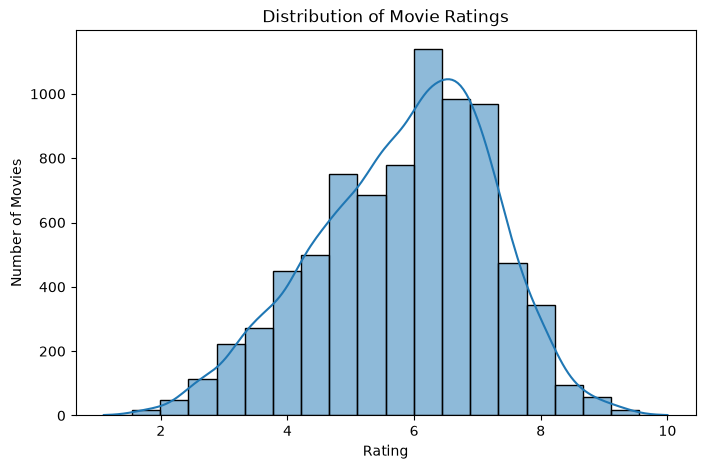

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.show()

In [24]:
df['Genre'].value_counts().head(10)

Genre
Drama                     1177
Drama, Romance             447
Action                     417
Action, Crime, Drama       417
Drama, Family              291
Action, Drama              271
Comedy                     259
Comedy, Drama              239
Romance                    234
Comedy, Drama, Romance     213
Name: count, dtype: int64

In [25]:
genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)

genre_rating.head(10)

Genre
History, Romance                  9.40
Documentary, Family, History      9.30
Documentary, Music                8.90
Documentary, Biography, Music     8.80
Documentary, Sport                8.60
Animation, Comedy, Family         8.30
Biography, Family                 8.30
Documentary, Thriller             8.25
Documentary, Biography, Family    8.25
Documentary, Biography, Sport     8.20
Name: Rating, dtype: float64

In [26]:
df[['Rating', 'Votes']].corr()

,Rating,Votes
Rating,1.000000,0.126635
Votes,0.126635,1.000000


In [27]:
director_stats = df.groupby('Director')['Rating'].agg(['mean', 'count'])

director_stats[director_stats['count'] >= 5].sort_values('mean', ascending=False).head(10)

,mean,count
Director,,
Anand Patwardhan,8.287500,8
Rajkumar Hirani,8.060000,5
Gulzar,7.521053,19
Shoojit Sircar,7.500000,7
Guru Dutt,7.487500,8
Kidar Nath Sharma,7.466667,9
Neeraj Pandey,7.460000,5
Anurag Kashyap,7.385714,14
Dibakar Banerjee,7.383333,6


In [28]:
df['Rating'].value_counts().sort_index()


Rating
1.1     1
1.4     1
1.6     3
1.7     5
1.8     4
       ..
9.3     9
9.4     4
9.6     1
9.7     1
10.0    1
Name: count, Length: 84, dtype: int64

In [29]:
df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']].nunique()

Genre        433
Director    3140
Actor 1     2552
Actor 2     2874
Actor 3     3065
dtype: int64

In [30]:
df[['Year', 'Duration', 'Rating', 'Votes']].corr()['Rating'].sort_values(ascending=False)

Rating      1.000000
Votes       0.126635
Duration   -0.030474
Year             NaN
Name: Rating, dtype: float64

In [31]:
df['Genre_Count'] = df['Genre'].apply(lambda x: len(x.split(',')) if x != 'Unknown' else 0)
df[['Genre', 'Genre_Count']].head()

,Genre,Genre_Count
1,Drama,1
3,"Comedy, Romance",2
5,"Comedy, Drama, Musical",3
6,"Drama, Romance, War",3
8,"Horror, Mystery, Thriller",3


In [37]:
df['Year'] = df['Year'].fillna(df['Year'].median())

In [57]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

df = df.dropna(subset=['Rating'])

df['Year'] = df['Year'].str.extract(r'(\d{4})')[0]
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Year'] = df['Year'].fillna(df['Year'].median())

df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Duration'] = df['Duration'].fillna(df['Duration'].median())

df['Votes'] = df['Votes'].str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = df[col].fillna('Unknown')

In [54]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

#Feature Selection

In [79]:
X = df[['Year', 'Duration', 'Votes', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]
y = df['Rating']

#training and testing the dataset

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
X_train.shape, X_test.shape

((6335, 8), (1584, 8))

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

categorical_features = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
numerical_features = ['Year', 'Duration', 'Votes']

#Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', 'passthrough', numerical_features)
])
#Model Training
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Year','Duration','Votes',...,'Actor 1','Actor 2','Actor 3']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conca

In [62]:
y_pred = model.predict(X_test)

In [63]:
y_pred[:10]

array([3.784, 5.325, 5.989, 6.603, 5.733, 6.462, 5.128, 6.798, 5.806,
       6.403])

#Model Evaluation

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 0.803261994949495
MSE: 1.17142592739899
R2 Score: 0.3699115245009138


In [65]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, gb_pred))
print("MSE:", mean_squared_error(y_test, gb_pred))
print("R2 Score:", r2_score(y_test, gb_pred))

MAE: 0.8550214905683425
MSE: 1.241785590506625
R2 Score: 0.33206635492834446


#Actual vs Predicted

In [69]:
result = X_test.copy()
result['Actual Rating'] = y_test
result['Predicted Rating'] = y_pred

result[['Actual Rating', 'Predicted Rating']].head(10)

,Actual Rating,Predicted Rating
9456,3.3,3.784
14816,5.3,5.325
3213,5.7,5.989
3778,7.2,6.603
5775,3.5,5.733
12203,7.2,6.462
12305,3.8,5.128
4650,6.9,6.798
8701,5.2,5.806
4707,7.4,6.403


#Save Final Model

In [66]:
import joblib

joblib.dump(model, "movie_rating_model.pkl")

['movie_rating_model.pkl']

In [68]:
loaded_model = joblib.load("movie_rating_model.pkl")

test_prediction = loaded_model.predict(X_test[:5])

print(test_prediction)

[3.784 5.325 5.989 6.603 5.733]


In [67]:
import os
os.path.exists("movie_rating_model.pkl")

True

## Conclusion

The movie rating prediction model was developed using the IMDb India Movies dataset. 
After data cleaning, exploratory data analysis, feature selection, preprocessing, 
and model training, Random Forest Regressor performed better than Gradient Boosting Regressor. 
The Random Forest model achieved an R² score of 0.37 and was selected as the final model.